In [21]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

with open("pokemon_data.json", "r") as file:
    data = json.load(file)
data_df = pd.DataFrame(data)
data_df_exploded = data_df.explode("types").rename(columns = {"types" : "type"})

In [18]:
pokemon_types = ["normal", "fire", "water", "grass", 
                 "electric", "ice", "fighting", "poison",
                 "ground", "flying", "psychic", "bug",
                 "rock", "ghost", "dragon", "dark",
                 "steel", "fairy"]

type_matchups = {"normal" : {"rock" : 0.5, "ghost" : 0, "steel" : 0.5},
                 "fire" : {"fire" : 0.5, "water" : 0.5, "grass" : 2, "ice" : 2,
                           "bug" : 2, "rock" : 0.5, "dragon" : 0.5, "steel" : 2},
                 "water" : {"fire" : 2, "water" : 0.5, "grass" : 0.5, "ground" : 2,
                            "rock" : 2, "dragon" : 0.5},
                 "grass" : {"fire" : 0.5, "water" : 0.5, "grass" : 0.5, "poison" : 0.5,
                            "ground" : 2, "flying" : 0.5, "bug" : 0.5, "rock" : 2,
                            "dragon" : 0.5, "steel" : 0.5},
                 "electric" : {"water" : 2, "grass" : 0.5, "electric" : 0.5, "ground" : 0,
                               "flying" : 2, "dragon" : 0.5},
                 "ice" : {"fire" : 0.5, "water" : 0.5, "grass" : 2, "ice" : 0.5,
                          "ground" : 2, "flying" : 2, "dragon" : 2, "steel" : 0.5},
                 "fighting" : {"normal" : 2, "ice" : 2, "poison" : 0.5, "flying" : 0.5,
                               "psychic" : 0.5, "bug" : 0.5, "rock" : 2, "ghost" : 0,
                               "dark" : 2, "steel" : 2, "fairy" : 0.5},
                 "poison" : {"grass" : 2, "poison" : 0.5, "ground" : 0.5, "rock" : 0.5,
                             "ghost" : 0.5, "steel" : 0, "fairy" : 2},
                 "ground" : {"fire" : 2, "grass" : 0.5, "electric" : 2, "poison" : 2,
                             "flying" : 0, "bug" : 0.5, "rock" : 2, "steel" : 2},
                 "flying" : {"grass" : 2, "electric" : 0.5, "fighting" : 2, "bug" : 2,
                             "rock" : 0.5, "steel" : 0.5},
                 "psychic" : {"fighting" : 2, "poison" : 2, "psychic" : 0.5, "dark" : 0,
                              "steel" : 0.5},
                 "bug" : {"fire" : 0.5, "grass" : 2, "fighting" : 0.5, "poison" : 0.5,
                          "flying" : 0.5, "psychic" : 2, "ghost" : 0.5, "dark" : 2,
                          "steel" : 0.5, "fairy" : 0.5},
                 "rock" : {"fire" : 2, "ice" : 2, "fighting" : 0.5, "ground" : 0.5,
                           "flying" : 2, "bug" : 2, "steel" : 0.5},
                 "ghost" : {"normal" : 0, "psychic" : 2, "ghost" : 2, "dark" : 0.5},
                 "dragon" : {"dragon" : 2, "steel" : 0.5, "fairy" : 0},
                 "dark" : {"fighting" : 0.5, "psychic" : 2, "ghost" : 2, "dark" : 0.5,
                           "fairy" : 0.5},
                 "steel" : {"fire" : 0.5, "water" : 0.5, "electric" : 0.5, "ice" : 2,
                            "rock" : 2, "steel" : 0.5, "fairy" : 2},
                 "fairy" : {"fire" : 0.5, "fighting" : 2, "poison" : 0.5, "dragon" : 2,
                            "dark" : 2, "steel" : 0.5}}

colours = {"normal" : "lightgray", "fire" : "red", 
           "water" : "dodgerblue", "grass" : "limegreen", 
            "electric" : "yellow", "ice" : "lightblue", 
            "fighting" : "maroon", "poison" : "purple",
            "ground" : "khaki", "flying" : "lightskyblue", 
            "psychic" : "fuchsia", "bug" : "yellowgreen",
            "rock" : "darkgoldenrod", "ghost" : "indigo", 
            "dragon" : "navy", "dark" : "black",
            "steel" : "grey", "fairy" : "pink"}

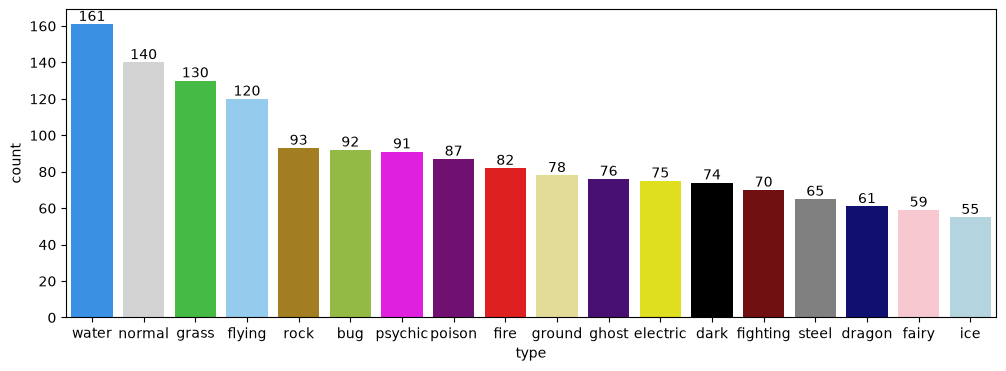

In [19]:
type_df = data_df_exploded.groupby("type")["name"].count().reset_index("type")
type_df = type_df.rename(columns = {"name" : "count"})

# resize graph to make x-axis labels legible
plt.figure(figsize=(12, 4))
graph = sns.barplot(data = type_df.sort_values("count", ascending = False), x = "type", y = "count", hue = "type", palette = colours, legend = False, errorbar = None)
# labelling bars
for container in graph.containers:
    graph.bar_label(container, fontsize = 10)


In [ ]:
data_df["types"].str.len().value_counts()
#data_df["types"].head()
data_df["primary"] = data_df['types'].str[0]
data_df["secondary"] = data_df['types'].str[1].fillna('none')

,name,types,primary,secondary
0,bulbasaur,"[grass, poison]",grass,poison
1,ivysaur,"[grass, poison]",grass,poison
2,venusaur,"[grass, poison]",grass,poison
3,charmander,[fire],fire,none
4,charmeleon,[fire],fire,none
5,charizard,"[fire, flying]",fire,flying
6,squirtle,[water],water,none
7,wartortle,[water],water,none
8,blastoise,[water],water,none
9,caterpie,[bug],bug,none


In [34]:
type_table = pd.crosstab(data_df['primary'], data_df['secondary'])
type_table = type_table.reindex(index =pokemon_types, columns=pokemon_types + ['none'], fill_value=0)
type_table

secondary,normal,fire,water,grass,electric,ice,fighting,poison,ground,flying,psychic,bug,rock,ghost,dragon,dark,steel,fairy,none
primary,,,,,,,,,,,,,,,,,,,
normal,0,0,1,2,0,0,2,0,1,30,4,0,0,2,1,0,0,4,74
fire,2,0,0,0,0,0,6,1,2,4,3,2,3,5,2,1,0,0,36
water,0,0,0,3,2,4,2,3,9,7,6,2,5,4,3,7,1,3,75
grass,3,1,0,0,0,2,4,14,1,6,3,0,0,5,6,5,3,4,45
electric,2,1,1,3,0,2,2,3,1,5,1,0,0,1,2,2,4,1,32
ice,0,1,4,0,0,0,0,0,3,1,4,2,1,1,0,0,2,1,19
fighting,0,1,1,0,1,1,0,2,0,1,2,0,0,1,0,1,1,0,28
poison,2,2,3,0,0,0,2,0,4,3,2,1,0,0,2,5,0,1,16
ground,2,0,0,2,1,0,1,0,0,2,2,0,3,4,2,3,5,0,16
